In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Clean-data/Data_Progressive_Clean.csv')
df.head()

,id_tabungan,counter_tabungan,tanggal_nabung,nama_goal,target_nominal,nominal_nabung,total_terkumpul,sisa_target,status,jarak_hari_nabung,persentase_terkumpul
0,TAB-0001,1,2021-06-12,Dana Darurat,9720000,1134942,1134942,8585058,Belum Selesai,0,11.68
1,TAB-0001,2,2021-06-26,Dana Darurat,9720000,948640,2083582,7636418,Belum Selesai,14,21.44
2,TAB-0001,3,2021-07-15,Dana Darurat,9720000,1056415,3139997,6580003,Belum Selesai,19,32.30
3,TAB-0001,4,2021-07-22,Dana Darurat,9720000,1036500,4176497,5543503,Belum Selesai,7,42.97
4,TAB-0001,5,2021-08-08,Dana Darurat,9720000,958707,5135204,4584796,Belum Selesai,17,52.83


In [3]:
df.describe()


,counter_tabungan,target_nominal,nominal_nabung,total_terkumpul,sisa_target,jarak_hari_nabung,persentase_terkumpul
count,32759.000000,3.275900e+04,3.275900e+04,3.275900e+04,3.275900e+04,32759.000000,32759.000000
mean,18.012790,1.683239e+07,1.155572e+06,8.409816e+06,8.394288e+06,19.720748,49.988025
std,18.538693,2.623384e+07,2.588807e+06,1.603340e+07,1.591669e+07,15.357752,29.590343
min,1.000000,1.000000e+05,1.540000e+02,1.000000e+04,0.000000e+00,0.000000,0.090000
25%,4.000000,2.730000e+06,7.037600e+04,9.157490e+05,8.461340e+05,11.000000,23.410000
50%,10.000000,7.030000e+06,1.636680e+05,2.660650e+06,2.698737e+06,19.000000,49.010000
75%,27.000000,1.394000e+07,8.018110e+05,7.125901e+06,7.002392e+06,26.000000,75.170000
max,95.000000,2.080000e+08,9.492078e+07,9.751000e+07,9.651145e+07,332.000000,100.000000


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32759 entries, 0 to 32758
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_tabungan           32759 non-null  object 
 1   counter_tabungan      32759 non-null  int64  
 2   tanggal_nabung        32759 non-null  object 
 3   nama_goal             32759 non-null  object 
 4   target_nominal        32759 non-null  int64  
 5   nominal_nabung        32759 non-null  int64  
 6   total_terkumpul       32759 non-null  int64  
 7   sisa_target           32759 non-null  int64  
 8   status                32759 non-null  object 
 9   jarak_hari_nabung     32759 non-null  int64  
 10  persentase_terkumpul  32759 non-null  float64
dtypes: float64(1), int64(6), object(4)
memory usage: 2.7+ MB
None


In [5]:
# ksih tau hapid
print(df[df['nominal_nabung'] == 0])

Empty DataFrame
Columns: [id_tabungan, counter_tabungan, tanggal_nabung, nama_goal, target_nominal, nominal_nabung, total_terkumpul, sisa_target, status, jarak_hari_nabung, persentase_terkumpul]
Index: []


In [6]:
df['tanggal_nabung'] = pd.to_datetime(df['tanggal_nabung'] , errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32759 entries, 0 to 32758
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_tabungan           32759 non-null  object        
 1   counter_tabungan      32759 non-null  int64         
 2   tanggal_nabung        32759 non-null  datetime64[ns]
 3   nama_goal             32759 non-null  object        
 4   target_nominal        32759 non-null  int64         
 5   nominal_nabung        32759 non-null  int64         
 6   total_terkumpul       32759 non-null  int64         
 7   sisa_target           32759 non-null  int64         
 8   status                32759 non-null  object        
 9   jarak_hari_nabung     32759 non-null  int64         
 10  persentase_terkumpul  32759 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(6), object(3)
memory usage: 2.7+ MB


In [7]:
# Sementara nanti hapus
df = df[df['persentase_terkumpul'] <= 100]


# EDA

### Univariate Analysis

In [8]:
numerical_kolom = ['target_nominal', 'nominal_nabung', 'persentase_terkumpul', 'jarak_hari_nabung']
statistic_descriptive = {}

for i in numerical_kolom:
    desc = df[i].describe()
    formatted = desc.apply(
        lambda x: (
            f"Rp {x:,.0f}" if pd.notnull(x) and i not in ['persentase_terkumpul','jarak_hari_nabung'] and desc.name != 'count' else f"{x:,.0f}" if pd.notnull(x) else x
        ))
    statistic_descriptive[i] = formatted


### Tanggal Nabung

In [9]:
# Distribusi Tanggal
print("DISTRIBUSI Tanggal Waktu")
print("-" * 40)

df['tahun'] = df['tanggal_nabung'].dt.year
df['bulan'] = df['tanggal_nabung'].dt.month
df['tahun_bulan'] = df['tanggal_nabung'].dt.to_period('M')

print("\nDistribusi Nabung Berdasarkan Tahun:")
print(df['tahun'].value_counts().sort_index())

print(f"\nRange Tanggal : {df['tanggal_nabung'].min()} - {df['tanggal_nabung'].max()}")

DISTRIBUSI Tanggal Waktu
----------------------------------------

Distribusi Nabung Berdasarkan Tahun:
tahun
2020     3119
2021     7265
2022    10768
2023     4948
2024     4325
2025     2302
2026       32
Name: count, dtype: int64

Range Tanggal : 2020-01-04 00:00:00 - 2026-01-10 00:00:00


### Insight
- Range Data Mulai dari 4 Januari 2020 Hingga 10 Januari 2026
- Tahun 2022 Menempati Posisi Pertama Dalam Banyak nya Distribusi Data, Disusul Tahun 2021 lalu 2023

###  target_nominal

In [10]:
i = 'target_nominal'
print(f"STATISTIK DESKRIPTIF {i}")
print("-" * 40)
print(f"\nSeluruh {i}:")
print(statistic_descriptive['target_nominal'])

STATISTIK DESKRIPTIF target_nominal
----------------------------------------

Seluruh target_nominal:
count         Rp 32,759
mean      Rp 16,832,386
std       Rp 26,233,840
min          Rp 100,000
25%        Rp 2,730,000
50%        Rp 7,030,000
75%       Rp 13,940,000
max      Rp 208,000,000
Name: target_nominal, dtype: object


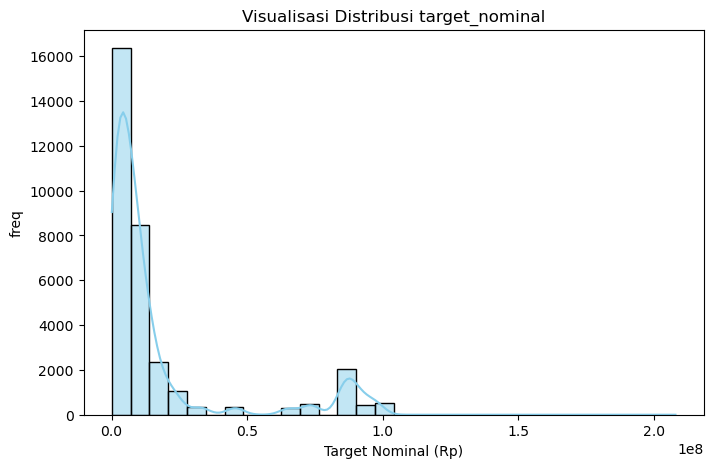

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['target_nominal'], bins=30, kde=True, color='skyblue')
plt.title(f'Visualisasi Distribusi {i}')
plt.xlabel('Target Nominal (Rp)')
plt.ylabel('freq')
plt.show()

# Insight

- Rata-rata target tabungan berada di Rp 16,832,386, menunjukkan nilai yang cukup tinggi.

- Median sebesar Rp 7,030,000 jauh lebih rendah dibandingkan rata-rata, menandakan distribusi yang condong ke kanan.

- Standar deviasi mencapai Rp 26,233,840, yang berarti variasi antar target sangat besar.

- Nilai minimum tercatat Rp 100,000, sehingga ada pengguna dengan target relatif kecil.

- Nilai maksimum mencapai Rp 208,000,000, menunjukkan adanya outlier yang sangat besar.

- Mayoritas nilai terkonsentrasi di kisaran rendah, sementara sebagian kecil target yang sangat besar membuat distribusi memiliki ekor panjang ke kanan.



### nominal_nabung

In [12]:
i = 'nominal_nabung'
print(f"STATISTIK DESKRIPTIF {i}")
print("-" * 40)
print(f"\nSeluruh {i}:")
print(statistic_descriptive[i])

STATISTIK DESKRIPTIF nominal_nabung
----------------------------------------

Seluruh nominal_nabung:
count        Rp 32,759
mean      Rp 1,155,572
std       Rp 2,588,807
min             Rp 154
25%          Rp 70,376
50%         Rp 163,668
75%         Rp 801,811
max      Rp 94,920,780
Name: nominal_nabung, dtype: object


# Insight
- Rata-rata nominal tabungan sekitar Rp 1,15 juta, tetapi median hanya Rp 163 ribu. Hal ini menandakan distribusi sangat tidak merata.

- Nilai minimum Rp 154 dan maksimum hampir Rp 95 juta memperlihatkan adanya rentang yang sangat lebar.

- Kuartil pertama Rp 70 ribu dan kuartil ketiga Rp 801 ribu, sehingga mayoritas pengguna menabung di kisaran ratusan ribu.

- Perbedaan besar antara mean dan median terjadi karena adanya outlier besar yang menarik rata-rata ke atas.

- Secara keseluruhan, distribusi sangat skewed ke kanan. Median dan IQR lebih tepat digunakan untuk menggambarkan kondisi umum dibandingkan mean.

### Persentase Terkumpul


In [13]:
i = 'persentase_terkumpul'
print(f"STATISTIK DESKRIPTIF {i}")
print("-" * 40)
print(f"\nSeluruh {i}:")
print(statistic_descriptive[i])

STATISTIK DESKRIPTIF persentase_terkumpul
----------------------------------------

Seluruh persentase_terkumpul:
count    32,759
mean         50
std          30
min           0
25%          23
50%          49
75%          75
max         100
Name: persentase_terkumpul, dtype: object


### Insight
- Rata-rata persentase tabungan yang terkumpul sekitar 50%.

- Median 49% menunjukkan sebagian besar pengguna sudah mencapai hampir separuh target.

- Standar deviasi 30% menandakan variasi yang besar antar pengguna.

- Nilai minimum 0% dan maksimum mencapai 100%, normal.

- Mayoritas pengguna berada di kisaran 20–75%, menunjukkan progres tabungan yang cukup konsisten.

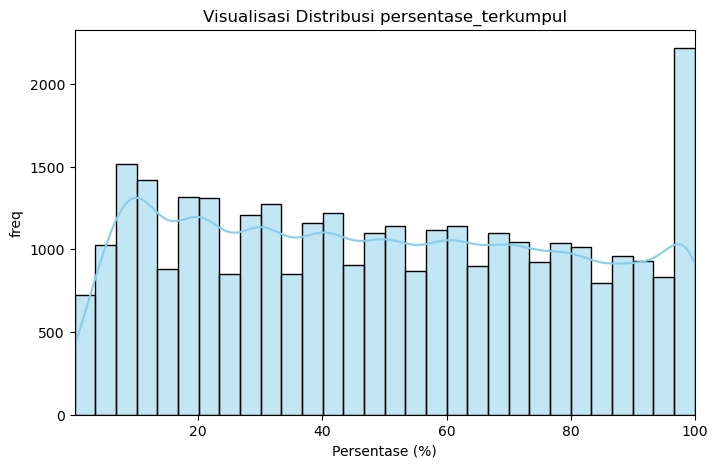

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['persentase_terkumpul'], bins=30, kde=True, color='skyblue')
plt.title(f'Visualisasi Distribusi persentase_terkumpul')
plt.xlabel('Persentase (%)')
plt.ylabel('freq')
plt.xlim(df['persentase_terkumpul'].min(), df['persentase_terkumpul'].max())
plt.show()


### Insight 
- Distribusi terlihat cukup merata di rentang 0–100%, dengan frekuensi tinggi di sekitar 40–60%.

- Ada kecenderungan peningkatan jumlah tabungan mendekati 100%, artinya cukup banyak pengguna yang berhasil mencapai target penuh.

- Puncak distribusi di sekitar 50% menunjukkan mayoritas pengguna berada di tahap pertengahan pencapaian target.

- Pola ini menandakan bahwa sebagian besar pengguna konsisten menabung, meskipun belum semua mencapai 100%.

- Adanya lonjakan di titik 100% memperlihatkan kelompok signifikan yang berhasil menyelesaikan target tabungan.

### Jarak Hari Nabung

In [15]:
i = 'jarak_hari_nabung'
print(f"STATISTIK DESKRIPTIF {i}")
print("-" * 40)
print(f"\nSeluruh {i}:")
print(statistic_descriptive[i])

STATISTIK DESKRIPTIF jarak_hari_nabung
----------------------------------------

Seluruh jarak_hari_nabung:
count    32,759
mean         20
std          15
min           0
25%          11
50%          19
75%          26
max         332
Name: jarak_hari_nabung, dtype: object


### Insight

- Rata-rata jarak antar tabungan adalah 20 hari, dengan median 19 hari. Ini menandakan mayoritas pengguna menabung sekitar dua hingga tiga minggu sekali.

- Kuartil pertama berada di 11 hari dan kuartil ketiga di 26 hari, sehingga sebagian besar pengguna menabung dalam rentang 1 – 4 minggu.

- Standar deviasi sebesar 15 hari menunjukkan variasi cukup besar antar pengguna.

- Nilai minimum 0 hari memperlihatkan ada kasus tabungan dilakukan pada hari yang sama.

- Nilai maksimum mencapai 332 hari, menandakan adanya outlier ekstrem berupa jeda tabungan hampir setahun.

## Bivariate Analysis

In [16]:
# # Hitung frekuensi setiap nama_goal
# goal_counts = df.groupby('nama_goal').size().sort_values(ascending=False)

# print(goal_counts.head(10))

### Nama Goal dan Persentase Terkumpul

In [17]:
# Buay kolom lama menabung
df['lama_menabung'] = df.groupby("id_tabungan")['tanggal_nabung'].transform(lambda x: (x.max() - x.min()).days)
df['hasil_akhir'] = df.groupby('id_tabungan')['status'].transform(lambda x: 'Selesai' if (x == 'Selesai').any() else 'Belum Selesai')

df.sample(5)

,id_tabungan,counter_tabungan,tanggal_nabung,nama_goal,target_nominal,nominal_nabung,total_terkumpul,sisa_target,status,jarak_hari_nabung,persentase_terkumpul,tahun,bulan,tahun_bulan,lama_menabung,hasil_akhir
11993,TAB-0835,5,2022-08-17,Modal Nikah/Tunangan,87840000,8834380,43645343,44194657,Belum Selesai,13,49.69,2022,8,2022-08,123,Belum Selesai
19224,TAB-1356,16,2023-01-29,Beli Raket Badminton/Sepatu Futsal,570000,28679,519580,50420,Belum Selesai,27,91.15,2023,1,2023-01,592,Selesai
21054,TAB-1449,7,2021-01-01,Tanpa Nama,1530000,51213,380605,1149395,Belum Selesai,27,24.88,2021,1,2021-01,772,Selesai
20252,TAB-1407,67,2024-12-06,Bayar Ukt Semester Depan,7760000,86694,6458595,1301405,Belum Selesai,26,83.23,2024,12,2024-12,1527,Selesai
8912,TAB-0610,7,2022-06-30,Beli Kasur Busa/Springbed,1450000,18000,130298,1319702,Belum Selesai,20,8.99,2022,6,2022-06,1401,Belum Selesai


In [18]:
print(f"Range lama menabung: {df['lama_menabung'].min()} - {df['lama_menabung'].max()} hari")
print(f"Rata-rata lama menabung: {df['lama_menabung'].mean():.0f} hari")

print("\nDistribusi hasil_akhir:")
print(df['hasil_akhir'].value_counts())
print(f"\nPersentase: {df['hasil_akhir'].value_counts(normalize=True).mul(100).round(2)}%")


Range lama menabung: 0 - 1882 hari
Rata-rata lama menabung: 697 hari

Distribusi hasil_akhir:
hasil_akhir
Selesai          24177
Belum Selesai     8582
Name: count, dtype: int64

Persentase: hasil_akhir
Selesai          73.8
Belum Selesai    26.2
Name: proportion, dtype: float64%


In [19]:
# Buat Dataset baru gabung menjadi 1 untuk setiap id yg sama
df_uni = df.groupby('id_tabungan').agg({
    'nama_goal': 'first',
    'target_nominal': 'first',
    'hasil_akhir': 'first',
    'tanggal_nabung': ['min', 'max'],
    'persentase_terkumpul': 'last'
}).reset_index()

# Flatten column names
df_uni.columns = ['id_tabungan', 'nama_goal', 'target_nominal', 'hasil_akhir', 
                    'tgl_mulai', 'tgl_akhir', 'persentase_terkumpul']

# Hitung lama menabung
df_uni['tgl_mulai'] = pd.to_datetime(df_uni['tgl_mulai'])
df_uni['tgl_akhir'] = pd.to_datetime(df_uni['tgl_akhir'])
df_uni['lama_menabung'] = (df_uni['tgl_akhir'] - df_uni['tgl_mulai']).dt.days

In [20]:
print("Dataset final (1 baris per ID)")
print(f"Total ID: {len(df_uni):,}")

df_belum_selesai = df_uni[
    (df_uni['hasil_akhir'] == 'Belum Selesai') & 
    (df_uni['lama_menabung'] > 180)
].copy()

df_belum_selesai.head()

Dataset final (1 baris per ID)
Total ID: 2,162


,id_tabungan,nama_goal,target_nominal,hasil_akhir,tgl_mulai,tgl_akhir,persentase_terkumpul,lama_menabung
36,TAB-0037,Rakit Pc Gaming,24690000,Belum Selesai,2021-05-10,2025-12-15,99.10,1680
48,TAB-0049,Modal Nikah/Tunangan,65260000,Belum Selesai,2024-04-11,2024-12-31,74.55,264
50,TAB-0052,Liburan Ke Bali/Jogja,4930000,Belum Selesai,2020-03-12,2021-02-17,40.23,342
64,TAB-0066,Dana Darurat,4850000,Belum Selesai,2022-03-14,2022-10-22,39.81,222
83,TAB-0085,Modal Usaha Thrift/F&B,9220000,Belum Selesai,2020-03-02,2023-10-03,89.23,1310


In [21]:
# Mencari Top 10 goal yang tidak selesai
top10_goals = df_belum_selesai['nama_goal'].value_counts().head(10).index
df_top10 = df_belum_selesai[df_belum_selesai['nama_goal'].isin(top10_goals)]
df_top10.head()

,id_tabungan,nama_goal,target_nominal,hasil_akhir,tgl_mulai,tgl_akhir,persentase_terkumpul,lama_menabung
36,TAB-0037,Rakit Pc Gaming,24690000,Belum Selesai,2021-05-10,2025-12-15,99.10,1680
48,TAB-0049,Modal Nikah/Tunangan,65260000,Belum Selesai,2024-04-11,2024-12-31,74.55,264
50,TAB-0052,Liburan Ke Bali/Jogja,4930000,Belum Selesai,2020-03-12,2021-02-17,40.23,342
64,TAB-0066,Dana Darurat,4850000,Belum Selesai,2022-03-14,2022-10-22,39.81,222
88,TAB-0090,Dana Darurat,13410000,Belum Selesai,2022-02-03,2022-09-01,3.59,210


In [22]:
result = df_top10.groupby('nama_goal')['persentase_terkumpul'].mean().sort_values()
result

nama_goal
Dana Darurat                     55.037273
Liburan Ke Bali/Jogja            59.217143
Beli Ipad/Tablet Nugas           62.011429
Modal Nikah/Tunangan             67.103617
Dp Motor Baru                    67.353750
Tanpa Nama                       67.775000
Beli Motor Bekas                 69.295000
Beli Hewan Qurban                69.566667
Rakit Pc Gaming                  74.000000
Beli Kamera Analog/Mirrorless    88.188889
Name: persentase_terkumpul, dtype: float64

### Insight

- Dari top 10 goal yang tabungan nya tidak selesai, Progress yang paling buruk berdasarkan persentase terkumpul adalah Dana Darurat.

### Jarak Hari Nabung dan Status = Selesai

In [23]:
df_selesai = df[
    (df['status'] == 'Selesai') &
    (df['tanggal_nabung'].between('2022-01-01', '2025-12-31'))
].copy()
print(f"Jumlah baris (setoran) dengan status Selesai: {len(df_selesai):,}")
print(f"Jumlah ID unik: {df_selesai['id_tabungan'].nunique():,}")

Jumlah baris (setoran) dengan status Selesai: 930
Jumlah ID unik: 930


In [24]:
print("="*50)
print("STATISTIK JARAK_HARI_NABUNG (Status: Selesai)")
print("="*50)

print(f"Rata-rata   : {df_selesai['jarak_hari_nabung'].mean():.1f} hari")
print(f"Median      : {df_selesai['jarak_hari_nabung'].median():.1f} hari")
print(f"Standar Dev : {df_selesai['jarak_hari_nabung'].std():.1f} hari")
print(f"Min         : {df_selesai['jarak_hari_nabung'].min()} hari")
print(f"Max         : {df_selesai['jarak_hari_nabung'].max()} hari")
print(f"Q1 (25%)    : {df_selesai['jarak_hari_nabung'].quantile(0.25):.1f} hari")
print(f"Q3 (75%)    : {df_selesai['jarak_hari_nabung'].quantile(0.75):.1f} hari")

STATISTIK JARAK_HARI_NABUNG (Status: Selesai)
Rata-rata   : 21.6 hari
Median      : 19.0 hari
Standar Dev : 19.9 hari
Min         : 0 hari
Max         : 294 hari
Q1 (25%)    : 12.0 hari
Q3 (75%)    : 26.8 hari


### Insight 
- Rata‑rata jarak antar setoran adalah 21,8 hari, menunjukkan pola menabung sekitar tiga minggu sekali.

- Median jarak adalah 19 hari, artinya separuh pengguna menabung lebih cepat dari 19 hari dan separuh lebih lambat.

- Standar deviasi sebesar 19,3 hari, menandakan variasi cukup tinggi antar pengguna.

- Nilai minimum adalah 0 hari, ada kasus langsung selesai tanpa jeda (sekali setor besar).

- Nilai maksimum mencapai 294 hari, menunjukkan ada pengguna yang menabung sangat jarang, hampir setahun sekali.

- Kuartil pertama (Q1) berada di 12 hari, seperempat pengguna menabung lebih cepat dari dua minggu.

- Kuartil ketiga (Q3) berada di 27 hari, tiga perempat pengguna menabung kurang dari satu bulan sekali.

# Visualisasi

 Q1 : "Dari 10 nama_goal dengan frekuensi tertinggi, mana yang memiliki rata-rata persentase pencapaian terendah untuk tabungan 'Belum Selesai' yang sudah berjalan lebih dari 180 hari?"

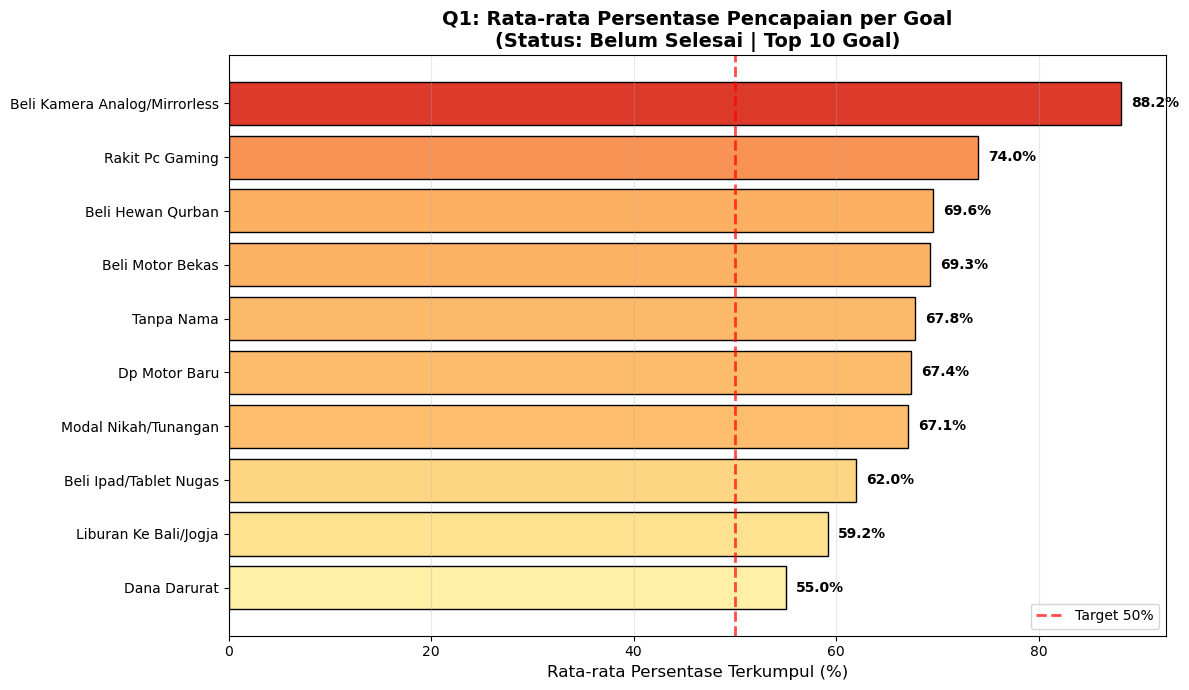

In [25]:
mean_per_goal = df_top10.groupby('nama_goal')['persentase_terkumpul'].mean().sort_values()
fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.RdYlGn_r(mean_per_goal.values / 100)

bars = ax.barh(mean_per_goal.index, mean_per_goal.values, color=colors, edgecolor='black')

for bar, val in zip(bars, mean_per_goal.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.axvline(x=50, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Target 50%')

ax.set_xlabel('Rata-rata Persentase Terkumpul (%)', fontsize=12)
ax.set_title('Q1: Rata-rata Persentase Pencapaian per Goal\n(Status: Belum Selesai | Top 10 Goal)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

#### Insight
- Dana Darurat adalah goal yang paling tertinggal pencapaiannya meskipun termasuk dalam top 10 paling sering dipilih.

- Hal ini menunjukkan bahwa user lebih konsisten menabung untuk tujuan yang menyenangkan (kamera, PC gaming, liburan) dibandingkan kebutuhan esensial seperti dana darurat.

- Ada indikasi bahwa motivasi emosional (reward, lifestyle) lebih kuat dibanding motivasi rasional (kebutuhan darurat).

---

Q2 : "Bagaimana distribusi jarak_hari_nabung (dalam hari) untuk tabungan dengan status 'Selesai pada tahun 2022-2025, dan berapa median jarak antar setoran?"

NameError: name 'median_value' is not defined

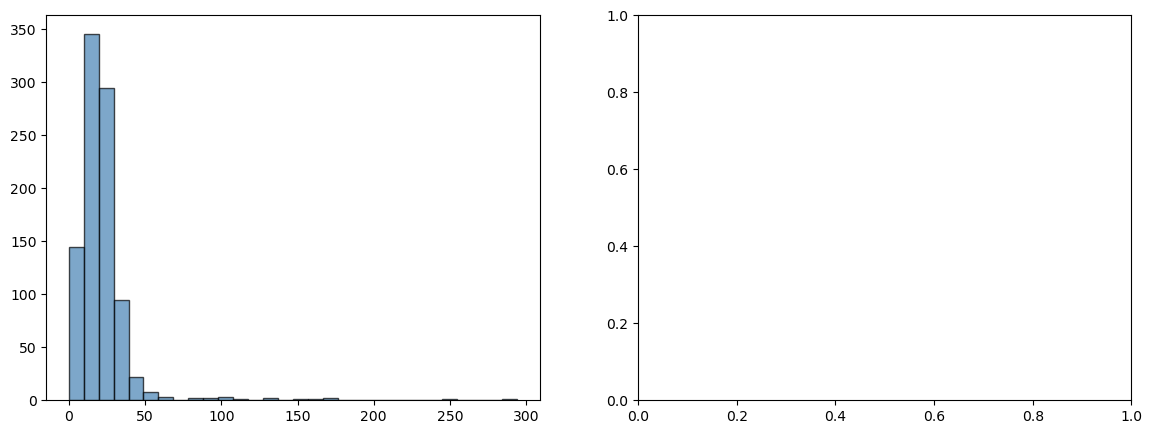

In [26]:
df_q2 = df_selesai.copy()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (distribusi)
ax1.hist(df_q2['jarak_hari_nabung'], bins=30, edgecolor='black', color='steelblue', alpha=0.7)
ax1.axvline(median_value, color='red', linestyle='--', linewidth=2, label=f'Median: {median_value:.0f} hari')
ax1.set_xlabel('Jarak Hari Nabung')
ax1.set_ylabel('Frekuensi')
ax1.set_title('Distribusi Jarak Nabung')
ax1.legend()

# Boxplot (ringkasan statistik)
ax2.boxplot(df_q2['jarak_hari_nabung'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7))
ax2.set_xlabel('Jarak Hari Nabung')
ax2.set_title('Ringkasan Statistik (Boxplot)')
ax2.axvline(median_value, color='red', linestyle='--', linewidth=2, label=f'Median: {median_value:.0f} hari')
ax2.legend()

plt.suptitle('Q2: Jarak Antar Setoran (Status: Selesai | Tahun 2022-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Insight
- Pola umum: pengguna yang berhasil menyelesaikan tabungan di periode 2022–2025 cenderung menabung sekitar 2–3 minggu sekali.

- Outlier menunjukkan adanya perilaku ekstrem: sebagian langsung menyelesaikan dalam waktu singkat (0 hari, sekali setor besar), sebagian lain menabung sangat jarang.

- Konsistensi menabung dalam interval ≤ 1 bulan tampaknya menjadi faktor penting keberhasilan.